# CNOT twopass
This file contains twopass initial-scan analysis plus a snapshot full-scan reference.

### Initial scan

In [1]:
%load_ext autoreload
%autoreload 2

# Initial scan
from analysis_utils import load_ft_scan, plot_rate_scan

initial_scan = load_ft_scan(
    "../results/cnot_twopass/initial_scan",
    p_values=[0.006, 0.008, 0.01, 0.012, 0.014, 0.016, 0.018, 0.02],
    L_values=[5, 7, 9, 13, 19],
    expected_repeats=1,
)
initial_scan.print_summary()


Loaded 40 requested CNOT Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]]


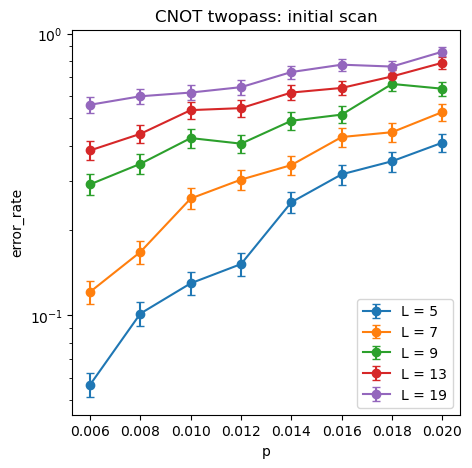

In [2]:
plot_rate_scan(
    initial_scan,
    title="CNOT twopass: initial scan",
    ylabel="error_rate",
)


### Snapshot full-scan reference

In [3]:
# No twopass full scan is available yet; use snapshot data as a reference.
from analysis_utils import fit_scaling_ansatz, print_scaling_ansatz_fit

snapshot_reference_scan = load_ft_scan(
    "../results/cnot_snapshot/full_scan/T∕2_CNOT_T∕2_2T",
    p_values=[0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020],
    L_values=[5, 7, 9, 13, 19],
    expected_repeats=5,
)
snapshot_reference_scan.print_summary()


Loaded 250 requested CNOT Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]]


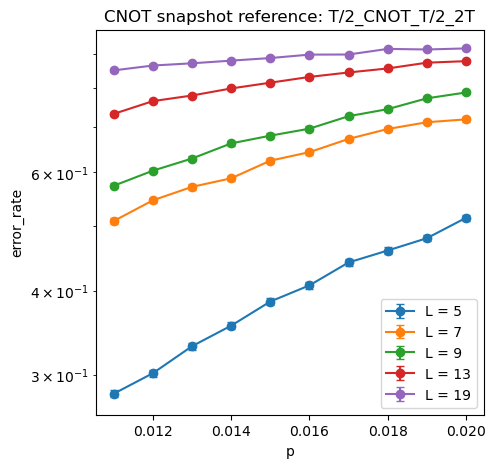

In [4]:
plot_rate_scan(
    snapshot_reference_scan,
    title="CNOT snapshot reference: T/2_CNOT_T/2_2T",
    ylabel="error_rate",
)


In [5]:
# Flattened arrays remain convenient for ad-hoc interactive fits.
p, L, rate, rate_error = snapshot_reference_scan.fit_arrays()


In [6]:
quadratic_fit = fit_scaling_ansatz(snapshot_reference_scan, polynomial_order=2)
print_scaling_ansatz_fit(quadratic_fit)


Fitted parameters: [ 2.12730741e+03  6.62500783e+01 -1.06711469e+03 -9.58606683e-01
 -2.15103103e-04]
Parameter standard deviations: [3.54622779e+04 2.05126247e+02 6.49543493e+03 1.54684164e+01
 6.92691261e-03]
Weighted absolute residual: 518.3154982791585


In [7]:
cubic_fit = fit_scaling_ansatz(snapshot_reference_scan, polynomial_order=3)
print_scaling_ansatz_fit(cubic_fit)


Fitted parameters: [ 4.28789219e+02  1.55091783e+01 -7.55036154e+02 -4.42452020e+00
 -8.64483331e-03 -5.63804203e-06]
Parameter standard deviations: [5.13476644e+03 4.91393667e+01 6.75708288e+03 5.42348832e+01
 1.92920676e-01 1.88969880e-04]
Weighted absolute residual: 517.6834525104249


In [8]:
quadratic_correction_fit = fit_scaling_ansatz(
    snapshot_reference_scan,
    polynomial_order=2,
    include_finite_size_correction=True,
)
print_scaling_ansatz_fit(quadratic_correction_fit)


Fitted parameters: [-2.37855750e-02  2.59240778e+00 -1.06969110e+00  2.93637726e+01
 -1.08661763e+02 -1.22770621e+17  3.86214338e-02]
Parameter standard deviations: [3.60452298e-03 2.14880768e-01 2.16978171e-01 3.35990421e+00
 1.30907478e+01 9.41098546e-20 3.43271324e-05]
Weighted absolute residual: 82.13396558481965


In [9]:
cubic_correction_fit = fit_scaling_ansatz(
    snapshot_reference_scan,
    polynomial_order=3,
    include_finite_size_correction=True,
)
print_scaling_ansatz_fit(cubic_correction_fit)


Fitted parameters: [ 8.51543243e-01  2.71783082e+01 -1.05717456e+03 -3.70971049e+03
 -4.29686495e+03 -1.64724750e+03 -7.68044188e+00  1.13309953e+00]
Parameter standard deviations: [4.00078485e+00 1.31363555e+02 1.70919049e+04 4.20165293e+04
 2.84171132e+04 3.30907282e+03 4.93274570e-01 3.67141861e-02]
Weighted absolute residual: 122.23099754730704


In [10]:
import numpy as np

px = 0.16
w1 = np.log(1/px - 1)
print(w1)

1.6582280766035324
